Missing values are common in real-world datasets and must be handled carefully to ensure data quality. There are three main strategies to handle missing values:

- 1️⃣ Remove Missing Values (If the missing data is small or irrelevant)
- 2️⃣ Impute Missing Values (If missing data is significant and needs replacement)
- 3️⃣ Predict or Infer Missing Values (Advanced techniques using ML models)

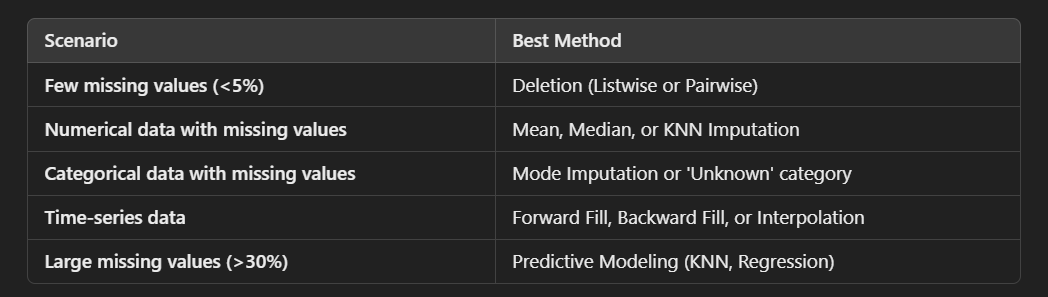

# Types of Missing Data

1. MCAR (Missing Completely at Random)

    - Data is missing purely by chance.

    - Example: A survey respondent skips a question randomly.

2. MAR (Missing at Random)

    - The missing data is related to some other observed data.

    - Example: Higher-income people tend to skip salary-related survey questions.

3. MNAR (Missing Not at Random)

    - The missing values depend on unobserved factors.

    - Example: Patients with severe illness are more likely to skip health-related surveys.

# Removing Missing Values
If a column has too many missing values or if a row with missing data isn't useful, we can remove them.

## Remove Rows with Missing Values

In [ ]:
df.dropna(inplace=True)  # Removes all rows with any missing values


### When to use?
- ✔️ If missing values are random and sparse (e.g., <5% of the dataset).
- ✔️ If dropping them doesn’t impact the dataset significantly.

## Remove Columns with Many Missing Values

In [ ]:
df.drop(columns=['column_name'], inplace=True)  # Removes a specific column


### When to use?
- ✔️ If a column has more than 50% missing values and is not useful.

# Imputing (Filling) Missing Values
If removing values results in loss of useful data, we can fill in the missing values.

## Fill with a Fixed Value

In [ ]:
df.fillna(0, inplace=True)  # Replace missing values with 0
df.fillna("Unknown", inplace=True)  # Replace missing categorical values


### When to use?
- ✔️ If missing values have no real meaning and can be safely replaced with a default value.

## Fill with Mean, Median, or Mode

In [ ]:
df['column_name'].fillna(df['column_name'].mean(), inplace=True)  # Mean
df['column_name'].fillna(df['column_name'].median(), inplace=True)  # Median
df['column_name'].fillna(df['column_name'].mode()[0], inplace=True)  # Mode


### When to use?
- ✔️ Mean: When the data is normally distributed (e.g., height, income).
- ✔️ Median: When there are outliers (e.g., house prices, salaries).
- ✔️ Mode: When working with categorical data (e.g., most common product category).

##  Forward or Backward Filling
For time-series or sequential data:

In [ ]:
df.fillna(method='ffill', inplace=True)  # Forward fill (uses previous value)
df.fillna(method='bfill', inplace=True)  # Backward fill (uses next value)


### When to use?
- ✔️ If missing values follow a pattern (e.g., stock prices, weather data).


# Predicting Missing Values (Advanced Method)
If missing values are significant, we can predict them using machine learning.

## Handling Missing Values Using Regression
Regression Imputation is an advanced technique where we predict missing values using a regression model trained on available data. This is useful when missing values depend on other features in the dataset.

### How Regression Imputation Works?
- 1️⃣ Identify the column with missing values (target variable).
- 2️⃣ Select other columns (features) that correlate with the missing column.
- 3️⃣ Train a regression model on rows where the target column is not missing.
- 4️⃣ Use the trained model to predict missing values.
- 5️⃣ Fill in missing values with the predicted values.

In [1]:
# Import Required Libraries
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

data = {
    'Age': [25, 30, 35, np.nan, 45, 50, 55, np.nan, 65, 70],
    'Salary': [50000, 60000, 75000, 80000, 90000, 100000, 110000, 115000, 130000, 140000],
    'Experience': [2, 5, 7, 9, 12, 15, 18, 20, 25, 30]
}

df = pd.DataFrame(data)
print("Original Data:")
df

Original Data:


,Age,Salary,Experience
0,25.0,50000,2
1,30.0,60000,5
2,35.0,75000,7
3,NaN,80000,9
4,45.0,90000,12
5,50.0,100000,15
6,55.0,110000,18
7,NaN,115000,20
8,65.0,130000,25
9,70.0,140000,30


In [2]:
# Split Data into Train & Test Sets:
    # Train set: Rows where "Age" is not missing.
    # Test set: Rows where "Age" is missing (we will predict these).


# Split data into known and unknown Age values
df_train = df[df['Age'].notna()]  # Rows where Age is known
df_test = df[df['Age'].isna()]    # Rows where Age is missing

# Define features (X) and target (y)
X_train = df_train[['Salary', 'Experience']]  # Independent variables
y_train = df_train['Age']  # Target variable

X_test = df_test[['Salary', 'Experience']]  # Independent variables for missing rows


In [3]:
# Train a Regression Model

# Train a Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict missing Age values
predicted_ages = model.predict(X_test)

# Fill missing Age values in the original DataFrame
df.loc[df['Age'].isna(), 'Age'] = predicted_ages

print("\nData after Regression Imputation:")
df


Data after Regression Imputation:


,Age,Salary,Experience
0,25.000000,50000,2
1,30.000000,60000,5
2,35.000000,75000,7
3,39.317079,80000,9
4,45.000000,90000,12
5,50.000000,100000,15
6,55.000000,110000,18
7,57.170280,115000,20
8,65.000000,130000,25
9,70.000000,140000,30


### 📌 When to Use Regression Imputation?
- ✅ When missing values depend on other features (e.g., Age depends on Salary & Experience).
- ✅ When dataset is small to medium-sized (training a model is feasible).
- ✅ When missing values are not completely random (MAR - Missing at Random).

### 🚨 When NOT to Use Regression Imputation?
- ❌ If missing values are completely random (MCAR) → Regression won't help.
- ❌ If the dataset is too large, training a model for imputation can be slow.
- ❌ If missing values are in categorical variables, you need to convert them first.

### Real-world example: Titanic dataset

In [10]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Load Titanic dataset from Seaborn
df = sns.load_dataset('titanic')

# Select relevant numerical columns
df = df[['age', 'fare', 'pclass', 'sibsp', 'parch']]
print("Original Data with Missing Values:")
df.head(10)

# The "Age" column has missing values (NaN). 

Original Data with Missing Values:


,age,fare,pclass,sibsp,parch
0,22.0,7.2500,3,1,0
1,38.0,71.2833,1,1,0
2,26.0,7.9250,3,0,0
3,35.0,53.1000,1,1,0
4,35.0,8.0500,3,0,0
5,NaN,8.4583,3,0,0
6,54.0,51.8625,1,0,0
7,2.0,21.0750,3,3,1
8,27.0,11.1333,3,0,2
9,14.0,30.0708,2,1,0


In [11]:
# Split data into rows with known and unknown Age values
df_train = df[df['age'].notna()]  # Rows where Age is known
df_test = df[df['age'].isna()]    # Rows where Age is missing

# Define features (X) and target (y)
X_train = df_train[['fare', 'pclass', 'sibsp', 'parch']]  # Independent variables
y_train = df_train['age']  # Target variable

X_test = df_test[['fare', 'pclass', 'sibsp', 'parch']]  # Features for missing values


In [12]:
# Train a Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict missing Age values
predicted_ages = model.predict(X_test)

# Fill missing Age values in the original dataset
df.loc[df['age'].isna(), 'age'] = predicted_ages

print("\nData after Regression Imputation:")
df.head(10)


Data after Regression Imputation:


,age,fare,pclass,sibsp,parch
0,22.000000,7.2500,3,1,0
1,38.000000,71.2833,1,1,0
2,26.000000,7.9250,3,0,0
3,35.000000,53.1000,1,1,0
4,35.000000,8.0500,3,0,0
5,27.525206,8.4583,3,0,0
6,54.000000,51.8625,1,0,0
7,2.000000,21.0750,3,3,1
8,27.000000,11.1333,3,0,2
9,14.000000,30.0708,2,1,0


## Handling Missing Values with KNN Imputation
K-Nearest Neighbors (KNN) Imputation is an advanced method for filling missing values based on the similarity of data points. Instead of using simple statistics like mean or median, KNN imputes missing values by finding the "K" closest (most similar) data points and averaging their values.

**🚨 Limitations:**

- Can introduce bias if features are weakly correlated.
- Does not work for categorical data without preprocessing.

### How Does KNN Imputation Work?
- 1️⃣ Find "K" nearest neighbors for a data point with missing values using Euclidean distance (or another metric).
- 2️⃣ Use the average (or weighted average) of the neighbors to fill the missing value.
- 3️⃣ Repeat for all missing values.

We use the `KNNImputer` class from `sklearn.impute` to fill in missing values.

In [4]:
import numpy as np
import pandas as pd
from sklearn.impute import KNNImputer

data = {
    'Age': [25, 30, np.nan, 35, 40, np.nan, 50],
    'Salary': [50000, 60000, 55000, np.nan, 80000, 75000, np.nan],
    'Experience': [2, 5, 3, 7, 10, np.nan, 15]
}

df = pd.DataFrame(data)
print("Original Data:")
df

Original Data:


,Age,Salary,Experience
0,25.0,50000.0,2.0
1,30.0,60000.0,5.0
2,NaN,55000.0,3.0
3,35.0,NaN,7.0
4,40.0,80000.0,10.0
5,NaN,75000.0,NaN
6,50.0,NaN,15.0


In [5]:
# Initialize KNN Imputer with k=3 (choosing 3 nearest neighbors)
imputer = KNNImputer(n_neighbors=3)

# Fit and transform the dataset
df_imputed = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)
# fits the imputer to your data and performs the imputation in one step

print("\nData after KNN Imputation:")
df_imputed


Data after KNN Imputation:


,Age,Salary,Experience
0,25.000000,50000.0,2.0
1,30.000000,60000.0,5.0
2,36.666667,55000.0,3.0
3,35.000000,65000.0,7.0
4,40.000000,80000.0,10.0
5,31.666667,75000.0,6.0
6,50.000000,65000.0,15.0


### 📌 How KNN Handles Missing Values
- 1️⃣ It finds the 3 nearest neighbors (rows) based on available features.
- 2️⃣ It calculates the average of those nearest values for missing entries.
- 3️⃣ It fills missing values accordingly.

### Choosing the Best "K" Value
- Small K (e.g., K=2 or K=3) → Uses very similar values but might be biased.
- Large K (e.g., K=10) → Uses more data but may introduce noise.
- Best practice: Try different values of K and evaluate the impact on model performance.

In [6]:
# Trying different K values
for k in [2, 3, 5, 7]:
    imputer = KNNImputer(n_neighbors=k)
    df_imputed = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)
    print(f"\nData after KNN Imputation with K={k}:")
    print(df_imputed)



Data after KNN Imputation with K=2:
    Age   Salary  Experience
0  25.0  50000.0         2.0
1  30.0  60000.0         5.0
2  42.5  55000.0         3.0
3  35.0  57500.0         7.0
4  40.0  80000.0        10.0
5  35.0  75000.0         7.5
6  50.0  67500.0        15.0

Data after KNN Imputation with K=3:
         Age   Salary  Experience
0  25.000000  50000.0         2.0
1  30.000000  60000.0         5.0
2  36.666667  55000.0         3.0
3  35.000000  65000.0         7.0
4  40.000000  80000.0        10.0
5  31.666667  75000.0         6.0
6  50.000000  65000.0        15.0

Data after KNN Imputation with K=5:
    Age   Salary  Experience
0  25.0  50000.0         2.0
1  30.0  60000.0         5.0
2  36.0  55000.0         3.0
3  35.0  64000.0         7.0
4  40.0  80000.0        10.0
5  36.0  75000.0         5.4
6  50.0  64000.0        15.0

Data after KNN Imputation with K=7:
    Age   Salary  Experience
0  25.0  50000.0         2.0
1  30.0  60000.0         5.0
2  36.0  55000.0         3.0


### 📌 When to Use KNN Imputation?
- ✅ When missing values are not random (related to other features).
- ✅ When dataset is small to medium-sized (KNN can be slow for large datasets).
- ✅ When numerical features are present (works best with continuous data).
- ✅ When relationships exist between variables (e.g., Salary & Experience).

### 🚨 When NOT to use KNN Imputation?
- ❌ If the dataset is very large → It can be slow.
- ❌ If missing values are too many → It may not be effective.
- ❌ If categorical data is involved → Convert categorical values before applying KNN.

### Real-world example: Titanic dataset

In [13]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import KNNImputer

# Load Titanic dataset
df = sns.load_dataset('titanic')

# Select relevant numerical columns
df = df[['age', 'fare', 'pclass', 'sibsp', 'parch']]
print("Original Data with Missing Values:")
df.head(10)

Original Data with Missing Values:


,age,fare,pclass,sibsp,parch
0,22.0,7.2500,3,1,0
1,38.0,71.2833,1,1,0
2,26.0,7.9250,3,0,0
3,35.0,53.1000,1,1,0
4,35.0,8.0500,3,0,0
5,NaN,8.4583,3,0,0
6,54.0,51.8625,1,0,0
7,2.0,21.0750,3,3,1
8,27.0,11.1333,3,0,2
9,14.0,30.0708,2,1,0


We'll use KNN Imputer to fill these missing values based on Fare, Pclass, SibSp, and Parch.

In [14]:
# Initialize KNN Imputer (k=5)
imputer = KNNImputer(n_neighbors=5)

# Apply KNN Imputation
df_imputed = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)

# Print dataset after imputation
print("\nData after KNN Imputation:")
df_imputed.head(10)


Data after KNN Imputation:


,age,fare,pclass,sibsp,parch
0,22.0,7.2500,3.0,1.0,0.0
1,38.0,71.2833,1.0,1.0,0.0
2,26.0,7.9250,3.0,0.0,0.0
3,35.0,53.1000,1.0,1.0,0.0
4,35.0,8.0500,3.0,0.0,0.0
5,24.8,8.4583,3.0,0.0,0.0
6,54.0,51.8625,1.0,0.0,0.0
7,2.0,21.0750,3.0,3.0,1.0
8,27.0,11.1333,3.0,0.0,2.0
9,14.0,30.0708,2.0,1.0,0.0


**🚨 Limitations:**

- Computationally expensive for large datasets.
- May not work well if missing data is randomly distributed (MCAR).
- K value selection is important (too low → unstable, too high → less accurate).

## Handling missing values with Multiple Imputation by Chained Equations (MICE)

### How It Works
- Creates multiple versions of the dataset with different imputed values.

- Runs regression models on the available data to predict missing values.

- Combines results to reduce bias.

In [ ]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# Creating Iterative Imputer (MICE)
mice_imputer = IterativeImputer(max_iter=10, random_state=42)
df_mice_imputed = pd.DataFrame(mice_imputer.fit_transform(df), columns=df.columns)

print(df_mice_imputed)


### Pros & Cons
- ✅ More accurate than simple methods.
- ✅ Reduces bias by considering relationships between variables.
- ✅ Works well for small & large datasets.

- ❌ Requires more computation than simpler methods.
- ❌ Results may vary across different runs.

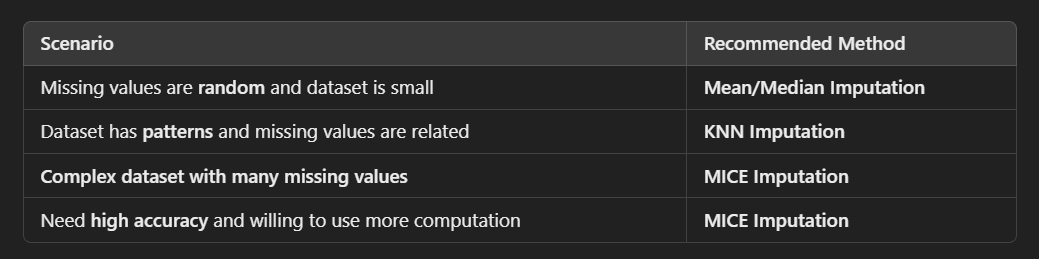

# Categorical data with missing values
Categorical data often contains missing values that need special treatment because we can't simply compute a "mean" or "median" like in numerical data. Below are common techniques to handle missing values in categorical columns.

## 1️⃣ Methods to Handle Missing Categorical Data

### (a) Mode Imputation (Most Frequent Category)
- Replace missing values with the most frequently occurring category.

**When to use?**

- When the missing values are random (MCAR).
- When the dataset is small, and we don’t want to introduce a new category.

In [1]:
import pandas as pd

# Sample Data
data = {'City': ['New York', 'Los Angeles', 'Chicago', 'Houston', None, 'Chicago', 'Houston', None]}
df = pd.DataFrame(data)
df


,City
0,New York
1,Los Angeles
2,Chicago
3,Houston
4,None
5,Chicago
6,Houston
7,None


In [2]:
# Impute missing values with Mode (Most Frequent Category)
mode_value = df['City'].mode()[0]  # Get the most common value
df['City'].fillna(mode_value, inplace=True)

df

C:\Users\SAURABH PRAKASH\AppData\Local\Temp\ipykernel_7448\2077816015.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['City'].fillna(mode_value, inplace=True)


,City
0,New York
1,Los Angeles
2,Chicago
3,Houston
4,Chicago
5,Chicago
6,Houston
7,Chicago


### (b) "Unknown" or "Missing" Category
- Replace missing values with a new category like 'Unknown' or 'Missing'.

**When to use?**

- When missing values might be meaningful (e.g., if missing job titles indicate unemployed).

In [3]:
df['City'].fillna('Unknown', inplace=True)


### (c) Predictive Imputation (Using ML Models)
- Use Machine Learning models like Decision Trees or KNN to predict missing values.

**When to use?**

- When there is a strong relationship between missing values and other features.

In [ ]:
from sklearn.impute import SimpleImputer
import numpy as np

df = pd.DataFrame({'City': ['New York', 'Los Angeles', np.nan, 'Chicago', 'Houston', np.nan, 'Chicago']})

# Use SimpleImputer to fill missing values with most frequent value
imputer = SimpleImputer(strategy='most_frequent')
df['City'] = imputer.fit_transform(df[['City']])

print(df)


### (d) One-Hot Encoding with Missing Values
- Treat missing values as a separate category during one-hot encoding.

**When to use?**

- If missing values hold meaning.

In [8]:
df = pd.DataFrame({'City': ['New York', 'Los Angeles', None, 'Chicago', 'Houston', None, 'Chicago']})
df['City'].fillna('Missing', inplace=True)
df_encoded = pd.get_dummies(df, columns=['City'])
df_encoded

C:\Users\SAURABH PRAKASH\AppData\Local\Temp\ipykernel_7448\1060694315.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['City'].fillna('Missing', inplace=True)


,City_Chicago,City_Houston,City_Los Angeles,City_Missing,City_New York
0,False,False,False,False,True
1,False,False,True,False,False
2,False,False,False,True,False
3,True,False,False,False,False
4,False,True,False,False,False
5,False,False,False,True,False
6,True,False,False,False,False


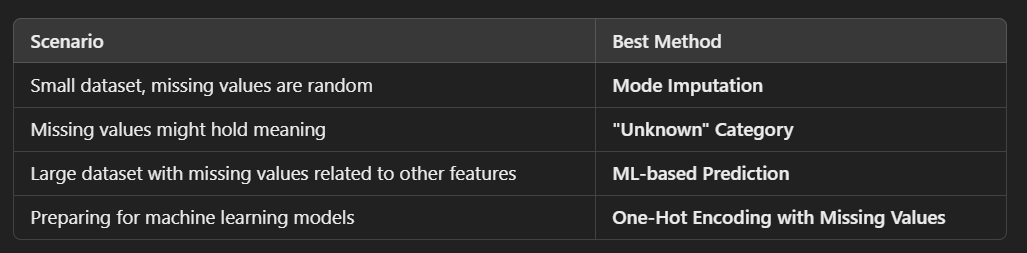

# Handling Missing Data in Time Series Data
Missing data in time series datasets is a common issue, and handling it properly is crucial for accurate forecasting and analysis. Unlike regular datasets, time series data has a temporal order, meaning missing values must be handled while preserving the sequence.

## Types of Missing Data in Time Series

### ✅ Completely Missing Timestamps
- The timestamp itself is missing (e.g., a sensor fails to record data for certain hours).

In [ ]:
Date        Temperature (°C)
2024-03-01    20
2024-03-02    21
2024-03-04    19  <- Missing 2024-03-03
2024-03-05    22

# Solution: Create a complete time index and fill missing timestamps.

### ✅ Partially Missing Values
- The timestamp exists, but some values are missing.

In [ ]:
Date        Temperature (°C)  Humidity (%)
2024-03-01    20                50
2024-03-02    NaN               52  <- Missing Temperature
2024-03-03    19                NaN  <- Missing Humidity
2024-03-04    21                55

# Solution: Use imputation techniques like forward fill, interpolation, or model-based approaches.

# Techniques for Handling Missing Time Series Data
## (a) Forward Fill (Pad Method)
- Fills missing values using the last available observation.

- Best for: Stock prices, temperature readings, sensor data (where values don’t change drastically).



In [9]:
import pandas as pd

# Creating a time series dataset
dates = pd.date_range(start='2024-03-01', periods=5, freq='D')
df = pd.DataFrame({'Date': dates, 'Temperature': [20, None, 19, None, 22]})
df.set_index('Date', inplace=True)

# Forward Fill
df.ffill(inplace=True)
df

,Temperature
Date,
2024-03-01,20.0
2024-03-02,20.0
2024-03-03,19.0
2024-03-04,19.0
2024-03-05,22.0


## (b) Backward Fill (bfill Method)
- Fills missing values using the next available observation.

- Best for: Data where future values are known (e.g., scheduled event prices).

In [ ]:
df.bfill(inplace=True)


## (c) Linear Interpolation
- Estimates missing values by drawing a straight line between the known points.

- Best for: Continuous numerical data like temperature, pressure, sales trends.

In [ ]:
df.interpolate(method='linear', inplace=True)
print(df)


## (d) Moving Average Imputation
- Replaces missing values with the average of nearby values.

- Best for: Stock market data, demand forecasting.

In [ ]:
# Example (3-day moving average)
df['Temperature'] = df['Temperature'].rolling(3, min_periods=1).mean()
print(df)


## (e) Seasonal Decomposition Imputation
- Uses seasonal patterns to predict missing values.

- Best for: Sales data, electricity usage, temperature trends.

In [ ]:
# Example (Using statsmodels)

from statsmodels.tsa.seasonal import seasonal_decompose

result = seasonal_decompose(df['Temperature'], model='additive', period=2)
df['Temperature'] = df['Temperature'].fillna(result.trend)
print(df)


## (f) Filling Missing Timestamps (Reindexing)
- If timestamps are missing, they should be added before imputation.

In [ ]:
full_dates = pd.date_range(start=df.index.min(), end=df.index.max(), freq='D')
df = df.reindex(full_dates)  # Adds missing dates
df.ffill(inplace=True)  # Fill missing values


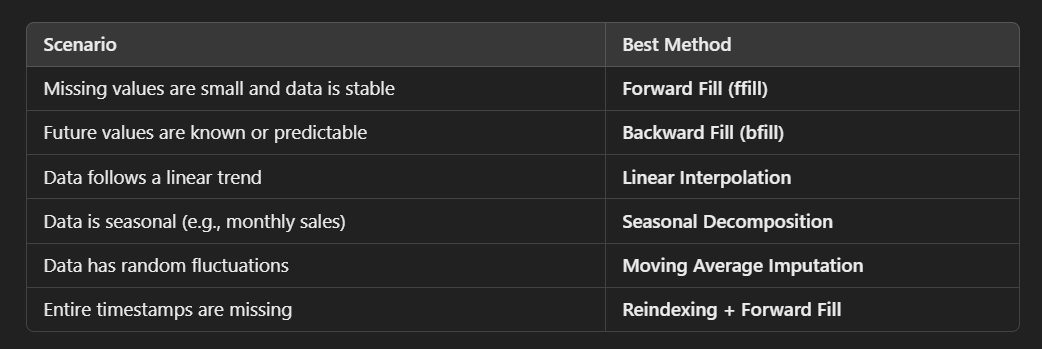

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Creating a time series dataset with missing values
dates = pd.date_range(start='2024-03-01', periods=10, freq='D')
temps = [20, 21, None, 22, None, 23, 24, None, 26, 27]
df = pd.DataFrame({'Date': dates, 'Temperature': temps})
df.set_index('Date', inplace=True)

df

,Temperature
Date,
2024-03-01,20.0
2024-03-02,21.0
2024-03-03,NaN
2024-03-04,22.0
2024-03-05,NaN
2024-03-06,23.0
2024-03-07,24.0
2024-03-08,NaN
2024-03-09,26.0


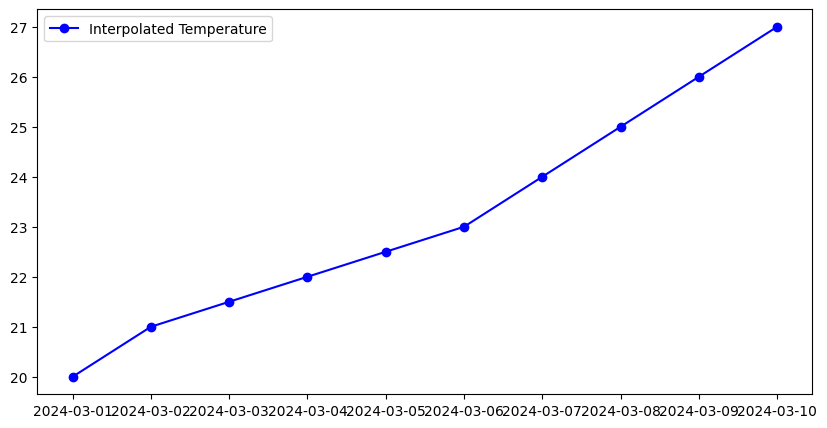

In [12]:
# Handling missing values
df['Temperature'] = df['Temperature'].interpolate(method='linear')

# Plotting results
plt.figure(figsize=(10, 5))
plt.plot(df.index, df['Temperature'], marker='o', linestyle='-', color='b', label='Interpolated Temperature')
plt.legend()
plt.show()
